## Credit_Scoring_model

## Dataset Description – German Credit Scoring Dataset

- **Dataset Name:** German Credit Scoring Dataset
- **Source:** Kaggle / UCI Machine Learning Repository
- **Total Records:** 1,000 loan applicants
- **Total Features:** 20 input features and 1 target variable
- **Problem Type:** Binary Classification
- **Target Variable:** Credit Risk (Good or Bad)
- **Missing Values:** No missing values
- **Objective:** Predict whether a customer is a good or bad credit risk based on financial and personal information.
- **Application:** Used for credit risk assessment and loan approval in banking and finance.

## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

## Load csv

In [3]:
df = pd.read_csv("german_credit_cleaned.csv")
df

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,other_debtors_guarantors,...,property,age,other_installment_plans,housing,num_curr_loans,job,num_people_provide_maint,telephone,is_foreign_worker,target
0,below_0,6,risky_acc_or_curr_loan_other,radio_tv,1169,unknown_no_saving_acc,above_7y,4,male:single,none,...,real_estate,67,none,own,2,skilled_official,1,yes,yes,good
1,below_200,48,curr_loans_paid_duly,radio_tv,5951,below_100,below_4y,2,female:divorced_or_married,none,...,real_estate,22,none,own,1,skilled_official,1,no,yes,bad
2,no_cheking_acc,12,risky_acc_or_curr_loan_other,education,2096,below_100,below_7y,2,male:single,none,...,real_estate,49,none,own,1,unskilled_resident,2,no,yes,good
3,below_0,42,curr_loans_paid_duly,furniture_equipment,7882,below_100,below_7y,2,male:single,guarantor,...,life_insurance_or_aggreements,45,none,for_free,1,skilled_official,2,no,yes,good
4,below_0,24,delay_in_past,car_new,4870,below_100,below_4y,3,male:single,none,...,unknown_or_no_property,53,none,for_free,2,skilled_official,2,no,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no_cheking_acc,12,curr_loans_paid_duly,furniture_equipment,1736,below_100,below_7y,3,female:divorced_or_married,none,...,real_estate,31,none,own,1,unskilled_resident,1,no,yes,good
996,below_0,30,curr_loans_paid_duly,car_used,3857,below_100,below_4y,4,male:divorced,none,...,life_insurance_or_aggreements,40,none,own,1,management_or_self_emp,1,yes,yes,good
997,no_cheking_acc,12,curr_loans_paid_duly,radio_tv,804,below_100,above_7y,4,male:single,none,...,car_or_other,38,none,own,1,skilled_official,1,no,yes,good
998,below_0,45,curr_loans_paid_duly,radio_tv,1845,below_100,below_4y,4,male:single,none,...,unknown_or_no_property,23,none,for_free,1,skilled_official,1,yes,yes,bad


## Understanding dataset

In [4]:
df.head

<bound method NDFrame.head of     checking_acc_status  duration                     cred_hist  \
0               below_0         6  risky_acc_or_curr_loan_other   
1             below_200        48          curr_loans_paid_duly   
2        no_cheking_acc        12  risky_acc_or_curr_loan_other   
3               below_0        42          curr_loans_paid_duly   
4               below_0        24                 delay_in_past   
..                  ...       ...                           ...   
995      no_cheking_acc        12          curr_loans_paid_duly   
996             below_0        30          curr_loans_paid_duly   
997      no_cheking_acc        12          curr_loans_paid_duly   
998             below_0        45          curr_loans_paid_duly   
999           below_200        45  risky_acc_or_curr_loan_other   

                 purpose  loan_amt       saving_acc_bonds  \
0               radio_tv      1169  unknown_no_saving_acc   
1               radio_tv      5951         

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_acc_status       1000 non-null   object
 1   duration                  1000 non-null   int64 
 2   cred_hist                 1000 non-null   object
 3   purpose                   1000 non-null   object
 4   loan_amt                  1000 non-null   int64 
 5   saving_acc_bonds          1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate          1000 non-null   int64 
 8   personal_stat_gender      1000 non-null   object
 9   other_debtors_guarantors  1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age                       1000 non-null   int64 
 13  other_installment_plans   1000 non-null   object
 14  housing                  

In [6]:
df.shape

(1000, 21)

In [7]:
df.describe()

,duration,loan_amt,installment_rate,present_residence_since,age,num_curr_loans,num_people_provide_maint
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [8]:
df.isnull().sum()

checking_acc_status         0
duration                    0
cred_hist                   0
purpose                     0
loan_amt                    0
saving_acc_bonds            0
present_employment_since    0
installment_rate            0
personal_stat_gender        0
other_debtors_guarantors    0
present_residence_since     0
property                    0
age                         0
other_installment_plans     0
housing                     0
num_curr_loans              0
job                         0
num_people_provide_maint    0
telephone                   0
is_foreign_worker           0
target                      0
dtype: int64

In [9]:
df["target"].value_counts()

target
good    700
bad     300
Name: count, dtype: int64

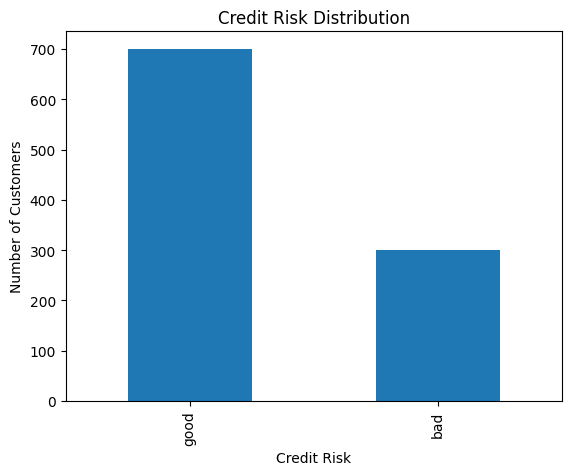

In [10]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")

plt.title("Credit Risk Distribution")
plt.xlabel("Credit Risk")
plt.ylabel("Number of Customers")
plt.show()

In [11]:
df["age"].describe()

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: age, dtype: float64

In [12]:
df["loan_amt"].describe()

count     1000.000000
mean      3271.258000
std       2822.736876
min        250.000000
25%       1365.500000
50%       2319.500000
75%       3972.250000
max      18424.000000
Name: loan_amt, dtype: float64

In [13]:
df["duration"].describe()

count    1000.000000
mean       20.903000
std        12.058814
min         4.000000
25%        12.000000
50%        18.000000
75%        24.000000
max        72.000000
Name: duration, dtype: float64

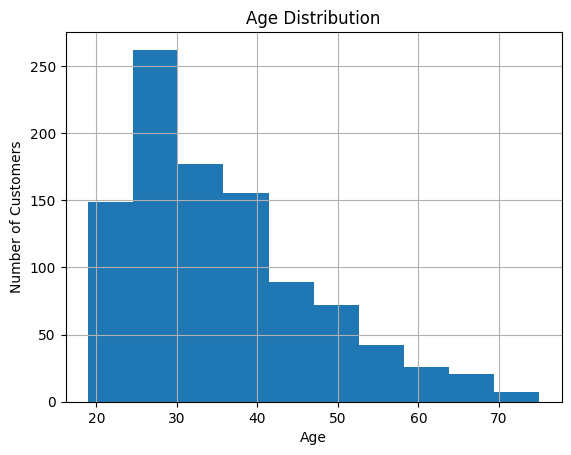

In [14]:
df["age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

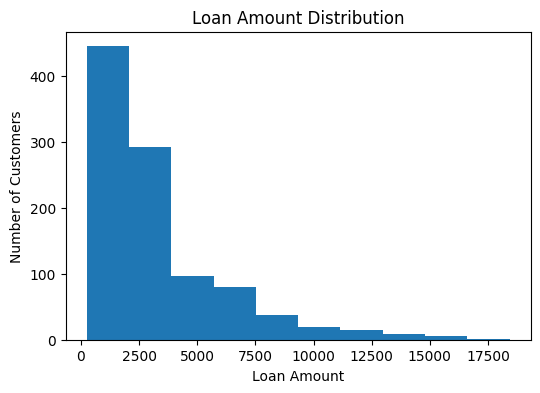

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df["loan_amt"], bins=10)

plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Customers")
plt.show()

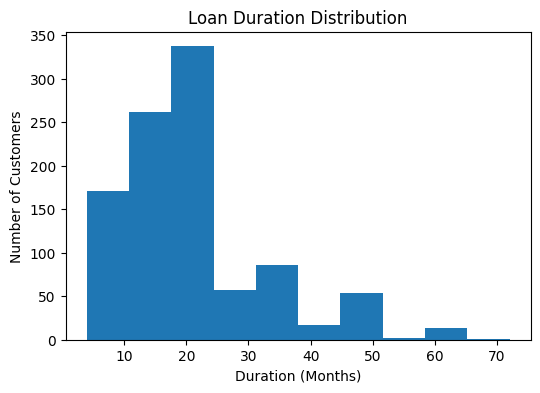

In [16]:
plt.figure(figsize=(6,4))
plt.hist(df["duration"], bins=10)

plt.title("Loan Duration Distribution")
plt.xlabel("Duration (Months)")
plt.ylabel("Number of Customers")
plt.show()

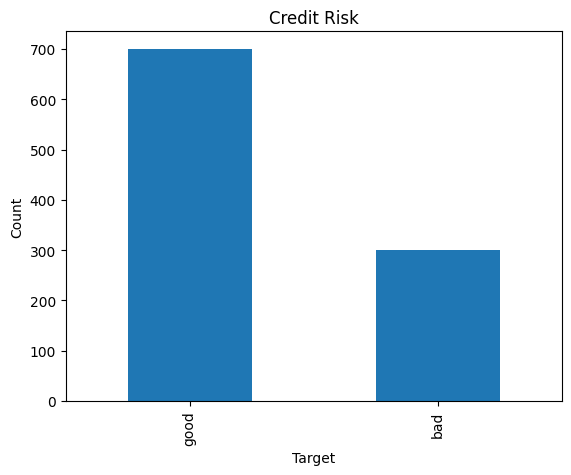

In [17]:
df["target"].value_counts().plot(kind="bar")

plt.title("Credit Risk")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

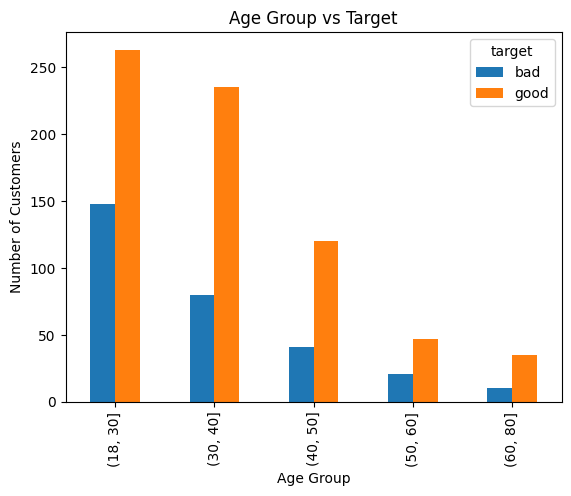

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

age_group = pd.cut(df["age"], bins=[18,30,40,50,60,80])

pd.crosstab(age_group, df["target"]).plot(kind="bar")

plt.title("Age Group vs Target")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   checking_acc_status       1000 non-null   object
 1   duration                  1000 non-null   int64 
 2   cred_hist                 1000 non-null   object
 3   purpose                   1000 non-null   object
 4   loan_amt                  1000 non-null   int64 
 5   saving_acc_bonds          1000 non-null   object
 6   present_employment_since  1000 non-null   object
 7   installment_rate          1000 non-null   int64 
 8   personal_stat_gender      1000 non-null   object
 9   other_debtors_guarantors  1000 non-null   object
 10  present_residence_since   1000 non-null   int64 
 11  property                  1000 non-null   object
 12  age                       1000 non-null   int64 
 13  other_installment_plans   1000 non-null   object
 14  housing                  

In [21]:
df.select_dtypes(include="object").columns

Index(['checking_acc_status', 'cred_hist', 'purpose', 'saving_acc_bonds',
       'present_employment_since', 'personal_stat_gender',
       'other_debtors_guarantors', 'property', 'other_installment_plans',
       'housing', 'job', 'telephone', 'is_foreign_worker', 'target'],
      dtype='object')

## Encode Target Column

In [22]:
df["target"] = df["target"].map({"good":1,"bad":0})

In [23]:
df["target"].head()

0    1
1    0
2    1
3    1
4    0
Name: target, dtype: int64

## Encode Remaining Categorical Columns



In [25]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [26]:
for column in df.select_dtypes(include="object").columns:
    df[column] = encoder.fit_transform(df[column])

In [27]:
df.head()

,checking_acc_status,duration,cred_hist,purpose,loan_amt,saving_acc_bonds,present_employment_since,installment_rate,personal_stat_gender,other_debtors_guarantors,...,property,age,other_installment_plans,housing,num_curr_loans,job,num_people_provide_maint,telephone,is_foreign_worker,target
0,1,6,4,7,1169,4,0,4,3,2,...,2,67,1,1,2,1,1,1,1,1
1,2,48,0,7,5951,1,2,2,0,2,...,2,22,1,1,1,1,1,0,1,0
2,3,12,4,4,2096,1,3,2,3,2,...,2,49,1,1,1,3,2,0,1,1
3,1,42,0,5,7882,1,3,2,3,1,...,1,45,1,0,1,1,2,0,1,1
4,1,24,1,1,4870,1,2,3,3,2,...,3,53,1,0,2,1,2,0,1,0


## Verify Encoding

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_acc_status       1000 non-null   int64
 1   duration                  1000 non-null   int64
 2   cred_hist                 1000 non-null   int64
 3   purpose                   1000 non-null   int64
 4   loan_amt                  1000 non-null   int64
 5   saving_acc_bonds          1000 non-null   int64
 6   present_employment_since  1000 non-null   int64
 7   installment_rate          1000 non-null   int64
 8   personal_stat_gender      1000 non-null   int64
 9   other_debtors_guarantors  1000 non-null   int64
 10  present_residence_since   1000 non-null   int64
 11  property                  1000 non-null   int64
 12  age                       1000 non-null   int64
 13  other_installment_plans   1000 non-null   int64
 14  housing                   1000 non-null  

## Separate Features and Target

In [29]:
X = df.drop("target", axis=1)
y = df["target"]

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [31]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(800, 20)
(200, 20)
(800,)
(200,)


## Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [34]:
rf = RandomForestClassifier(random_state=42)

In [35]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [36]:
y_pred = rf.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.775


In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 25  34]
 [ 11 130]]


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.42      0.53        59
           1       0.79      0.92      0.85       141

    accuracy                           0.78       200
   macro avg       0.74      0.67      0.69       200
weighted avg       0.76      0.78      0.76       200



In [40]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_pred)

print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.6728573145810794


In [41]:
importance = rf.feature_importances_

for feature, score in zip(X.columns, importance):
    print(feature, ":", score)

checking_acc_status : 0.10391424323401133
duration : 0.09396940683069349
cred_hist : 0.053217696402076874
purpose : 0.06771189827084637
loan_amt : 0.13859110462393054
saving_acc_bonds : 0.04728190295605425
present_employment_since : 0.05273701815632448
installment_rate : 0.04750999898580167
personal_stat_gender : 0.034206988471003424
other_debtors_guarantors : 0.017059483857168187
present_residence_since : 0.041295638830104286
property : 0.04117374540297248
age : 0.11235919310951621
other_installment_plans : 0.03133783957682102
housing : 0.02865509168286148
num_curr_loans : 0.021981941334274113
job : 0.0328703040673107
num_people_provide_maint : 0.01077328562671485
telephone : 0.02033500577465502
is_foreign_worker : 0.003018212806859315


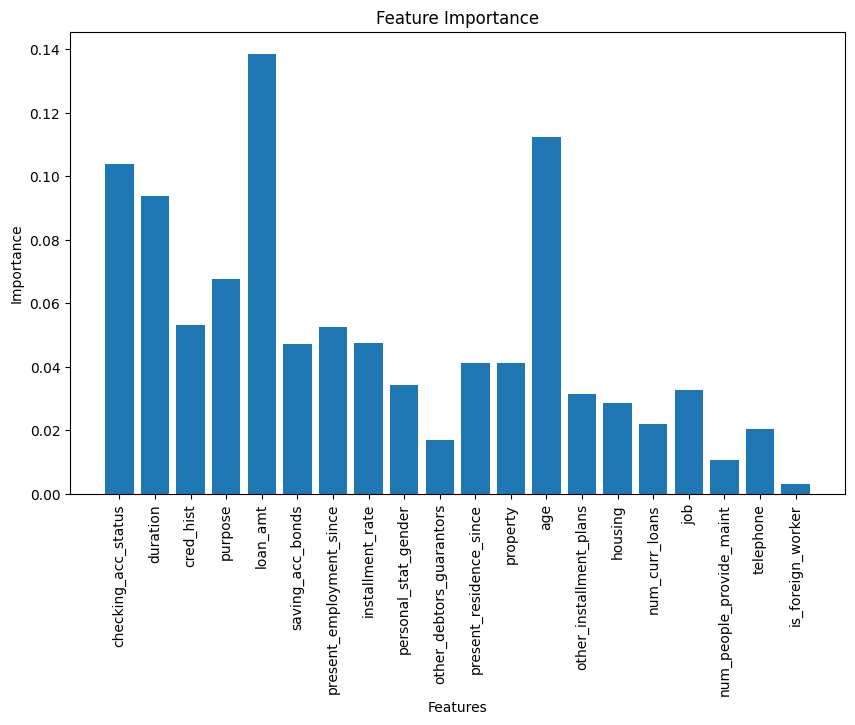

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.bar(X.columns, rf.feature_importances_)

plt.xticks(rotation=90)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()